In [1]:
import fnmatch
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import glob

from sessionlists import (dist60, dist90, dist120, TM20, TM10, TM2, TMrev2, TMrev10, TMrev20)
from utils import *
from plotting import *
from model_functions import *
from initialize_notebook import initialize_notebook

plt.style.use('./Figures/paper.mplstyle')

In [2]:
root, rat_lists, rat_markers, (example_rat, example_session), GENERAL_PLOT_PARAMS = initialize_notebook()
intact_rats, DSlesioned_rats, VSlesioned_rats, sham_rats, all_rats = rat_lists

alpha_0, alpha_t, alpha_u, gamma_0, gamma_t, gamma_u, mu_0, mu_t, mu_u, sigma_0, sigma_t, sigma_u = pickle.load(open("picklejar/ModelsFitsAllRats.p", "rb"))

Found 84 rats in the DATA folder
Listed 57 rats in total, of which 19 are intact (8♀, 11♂), 19 DS lesions, 15 VS lesions and 4 shams.
Example rat is RatM00, example session: RatM00_2021_07_22_16_13_03


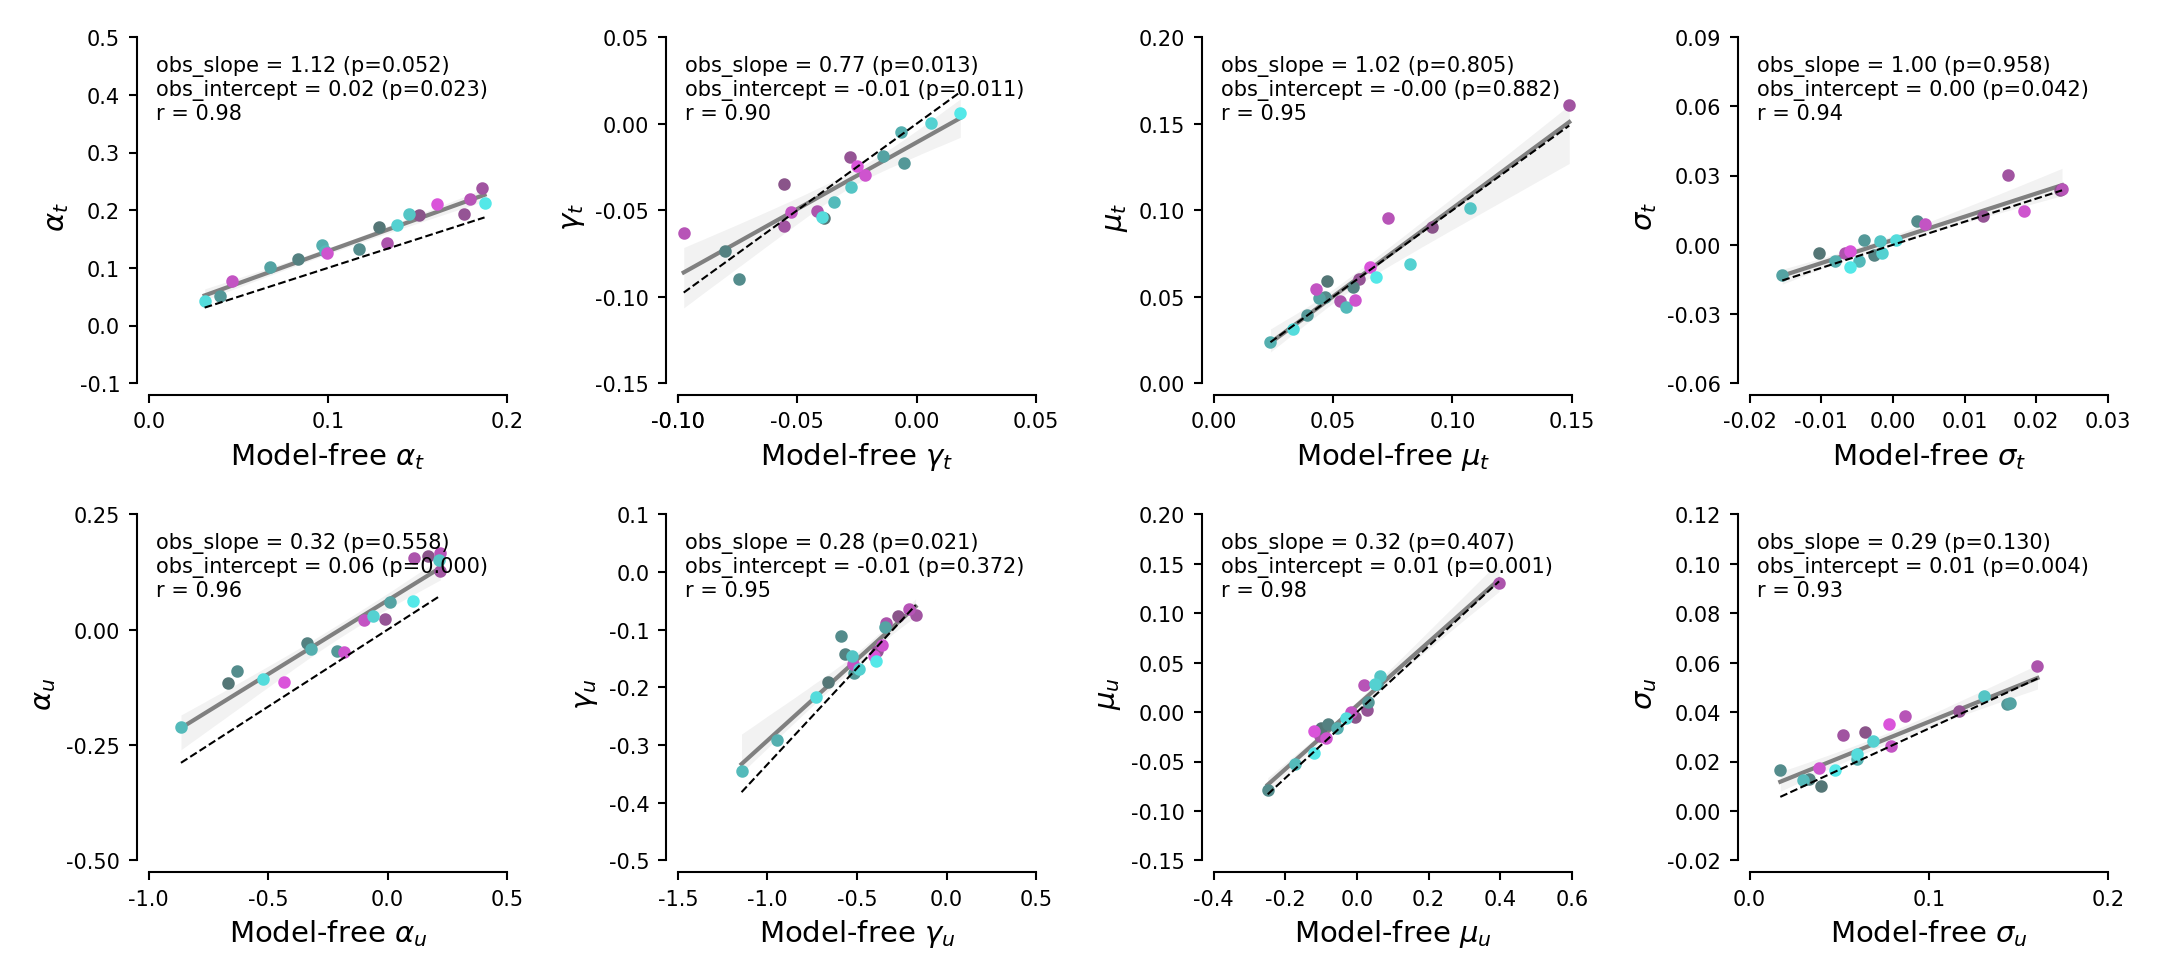

In [ ]:
params = {'alpha_t': {'var': alpha_t, 'ticks': GENERAL_PLOT_PARAMS['alpha_t']['yticks_I'], 'mf_ticks': [0, 0.1, 0.2], 'label': r'$\alpha_t$', 'picklename': "timeinZone.p"},
          'alpha_u': {'var': alpha_u, 'ticks': GENERAL_PLOT_PARAMS['alpha_u']['yticks_I'], 'mf_ticks': [-1, -0.5, 0, 0.5], 'label': r'$\alpha_u$', 'picklename': "timeinZone.p"},
          'gamma_t': {'var': gamma_t, 'ticks': GENERAL_PLOT_PARAMS['gamma_t']['yticks_I'], 'mf_ticks': [-0.1, -0.1, -0.05, 0, 0.05], 'label': r'$\gamma_t$', 'picklename': "timeinZone.p"},
          'gamma_u': {'var': gamma_u, 'ticks': GENERAL_PLOT_PARAMS['gamma_u']['yticks_I'], 'mf_ticks': [-1.5, -1, -0.5, 0, 0.5], 'label': r'$\gamma_u$', 'picklename': "timeinZone.p"}, 
          'mu_t': {'var': mu_t, 'ticks': GENERAL_PLOT_PARAMS['mu_t']['yticks_I'], 'mf_ticks': [0, 0.05, 0.1, 0.15], 'label': r'$\mu_t$', 'picklename': "timeRun.p"},
          'mu_u': {'var': mu_u, 'ticks': GENERAL_PLOT_PARAMS['mu_u']['yticks_I'], 'mf_ticks': [-0.4, -0.2, 0, 0.2, 0.4, 0.6], 'label': r'$\mu_u$', 'picklename': "timeRun.p"}, 
          'sigma_t': {'var': sigma_t, 'ticks': GENERAL_PLOT_PARAMS['sigma_t']['yticks_I'], 'mf_ticks': [-0.02, -0.01, 0, 0.01, 0.02, 0.03], 'label': r'$\sigma_t$', 'picklename': "timeRun.p"},
          'sigma_u': {'var': sigma_u, 'ticks': GENERAL_PLOT_PARAMS['sigma_u']['yticks_I'], 'mf_ticks': [0, 0.1, 0.2], 'label': r'$\sigma_u$', 'picklename': "timeRun.p"}}


def compare_MB_MF(x, y, ax=None,
                  slope_h0=1,
                  n_perm=10000):
    if ax is None:
        fig, ax = plt.subplots(figsize=(cm2inch(5), cm2inch(5)))
    # fit with cruve fit
    f = lambda x, a, b: a*x + b
    params, cov = curve_fit(f, x, y, p0=[1, 0])
    a, b = params
    a_se = np.sqrt(cov[0,0]) # s
    b_se = np.sqrt(cov[1,1]) # i

    # ci fitted line
    xi = np.linspace(min(x), max(x), 200)
    yi = f(xi, a, b)
    ax.plot(xi, yi, color="gray", zorder=0)

    ps = []
    for _ in range(n_perm):
        idx = np.random.randint(0, len(x), len(x))
        xb, yb = x[idx], y[idx]
        _p, _ = curve_fit(f, xb, yb, p0=[1,0])
        ps.append(_p)
    ps = np.array(ps)
    lower = np.percentile(np.array([p[0]*xi + p[1] for p in ps]), 2.5, axis=0)
    upper = np.percentile(np.array([p[0]*xi + p[1] for p in ps]), 97.5, axis=0)
    ax.fill_between(xi, lower, upper, color="gray", alpha=.1, zorder=0, lw=0)

    # shuffle to get p-value
    observed_slope = a
    shuffled_slopes = []
    for _ in range(n_perm):
        y_perm = np.random.permutation(y)
        _p, _ = curve_fit(f, x, y_perm, p0=[1,0])
        shuffled_slopes.append(_p[0])
    shuffled_slopes = np.array(shuffled_slopes)
    p_perm = (np.abs(shuffled_slopes) >= np.abs(observed_slope)).mean()

    # Wald test obs slope == slope_h0
    z = (a - slope_h0) / a_se
    p_slope = 2 * (1 - stats.norm.cdf(abs(z)))

    # Wald test obs intercept == 0
    z0 = b / b_se
    p_int = 2 * (1 - stats.norm.cdf(abs(z0)))


    ax.annotate(f"obs_slope = {a:.2f} (p={p_slope:.3f})\n"
                f"obs_intercept = {b:.2f} (p={p_int:.3f})\n"
                # f"perm p={p_perm:.3f}\n"
                f"r = {np.corrcoef(x, y)[0,1]:.2f}",
                xy=(0.05, 0.95), xycoords='axes fraction',
                ha="left", va="top", fontsize=5)

    ax.plot(xi, slope_h0*xi, color="black", ls='--', lw=0.5)


def compare_model_free(params, varname, root=root, animal_list=intact_rats, session_list=dist120, cond='120', ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(cm2inch(5), cm2inch(5)))
    model_free_values = {animal: 0 for animal in animal_list}

    for animal in animal_list:

        all_10, all_90 = [], []
        all_blocks = [[] for _ in range(6)]
        for session in matchsession(animal, session_list):
            l, r = get_from_pickle(root, animal, session, name=params[varname]['picklename'])
            data = [l[i] + r[i] for i in range(12)]

            # concatenate 10% and 90% bins
            data90 = np.concatenate(data[0::2])   # bins 0,2,4,6,8,10
            data10 = np.concatenate(data[1::2])   # bins 1,3,5,7,9,11
            data10 = data10[data10 > 0]
            data90 = data90[data90 > 0]
            all_90.extend(data90)
            all_10.extend(data10)

            # concatenate time bins
            for i in range(6):  # bins [0-1], [2-3]...
                data_k = np.array(data[2*i])
                data_k1 = np.array(data[2*i+1])  
                data_k = data_k[data_k > 0]
                data_k1 = data_k1[data_k1 > 0]
                all_blocks[i].extend(np.concatenate([data_k, data_k1]))
       

        if varname in ['alpha_u', 'gamma_u']:
            (model_free_alpha_u_90, t90, model_free_gamma_u_90), _ = wald_fit(all_90)
            (model_free_alpha_u_10, t10, model_free_gamma_u_10), _ = wald_fit(all_10)
            model_free_alpha_u = model_free_alpha_u_10 - model_free_alpha_u_90
            model_free_gamma_u = model_free_gamma_u_10 - model_free_gamma_u_90
            var_to_plot = model_free_alpha_u if 'alpha' in varname else model_free_gamma_u
            slope_h0 = 1/3

        elif varname in ['mu_u', 'sigma_u']:
            model_free_mu_u_90, model_free_sigma_u_90 = stats.cauchy.fit(all_90)
            model_free_mu_u_10, model_free_sigma_u_10 = stats.cauchy.fit(all_10)
            model_free_mu_u = model_free_mu_u_10 - model_free_mu_u_90
            model_free_sigma_u = model_free_sigma_u_10 - model_free_sigma_u_90
            var_to_plot = model_free_mu_u if 'mu' in varname else model_free_sigma_u
            slope_h0 = 1/3

        elif varname in ['alpha_t', 'gamma_t']:
            fit = np.array([wald_fit(all_blocks[k])[0] for k in range(6)])
            deltas = np.diff(fit, axis=0)
            model_free_alpha_t, _, model_free_gamma_t = np.mean(deltas, axis=0)
            var_to_plot = model_free_alpha_t if 'alpha' in varname else model_free_gamma_t
            slope_h0 = 1

        elif varname in ['mu_t', 'sigma_t']:
            fit = np.array([stats.cauchy.fit(all_blocks[k]) for k in range(6)])
            deltas = np.diff(fit, axis=0)
            model_free_mu_t, model_free_sigma_t = np.mean(deltas, axis=0)
            var_to_plot = model_free_mu_t if 'mu' in varname else model_free_sigma_t
            slope_h0 = 1

        ax.scatter(var_to_plot, params[varname]['var'][animal][cond], color=rat_markers[animal][0], s=4)

        model_free_values[animal] = var_to_plot

    y = [params[varname]['var'][animal]['120'] for animal in animal_list]
    x = [model_free_values[animal] for animal in animal_list]   
    compare_MB_MF(np.array(x), np.array(y), ax, slope_h0=slope_h0)

    ax.set_ylabel(params[varname]['label'])
    ax.set_xlabel("Model-free " + params[varname]['label'])
    ax.set_yticks(params[varname]['ticks'])
    ax.set_ylim(params[varname]['ticks'][0], params[varname]['ticks'][-1])
    ax.set_xticks(params[varname]['mf_ticks'])
    ax.set_xlim(params[varname]['mf_ticks'][0], params[varname]['mf_ticks'][-1])
    space_axes(ax)


fig, axs = plt.subplots(2, 4, figsize=(cm2inch(18), cm2inch(8)))
compare_model_free(params, 'alpha_t', ax=axs[0, 0])
compare_model_free(params, 'gamma_t', ax=axs[0, 1])
compare_model_free(params, 'mu_t', ax=axs[0, 2])
compare_model_free(params, 'sigma_t', ax=axs[0, 3])

compare_model_free(params, 'alpha_u', ax=axs[1, 0])
compare_model_free(params, 'gamma_u', ax=axs[1, 1])
compare_model_free(params, 'mu_u', ax=axs[1, 2])
compare_model_free(params, 'sigma_u', ax=axs[1, 3])